In [2]:
import sys
sys.path.append("../")

import numpy as np 
import pickle
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter

from scipy.signal import convolve, gaussian

from vi_rnn.saving import load_model
from vi_rnn.utils import *
from vi_rnn.load_data import * 

from fixed_points.find_fixed_points_analytic import find_fixed_points_analytic
from scipy.special import binom
%matplotlib inline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score 

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']

In [3]:
config = {
    'data_dir': '../data/recordings/nk341_mPFC/', 
    'dales_law': True,
    'out_dir': "../models/dtt/",
    'sampling_rate': 30_000,
    'bin_size': 0.1,
    'fr_threshold': 0.5,
    'threshold_neurons': True,
    'z_score_neuromod': True,
    'z_score_neurons': True,
    'deconvolve': False,
    'convolve_spikes': True,
    'normalize_neuromod': True,
    'center_neuromod': False,
    'load_physiology': False,
    'shuffle': False
}

In [4]:
spikes, spike_counts, neuromod_activity, trials_df, cell_types = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_test_end'] = int(data_dur - 0.75 * baseline_dur) 

config['baseline_train_start'] = config['baseline_test_end'] 
config['baseline_train_end'] = int(data_dur) 

# prepare dataset 
x_test, s_test, stim_arr_test, seq_periods, white_noise_trial_avgs_train, airpuff_trial_avgs_train, reward_trial_avgs_train = prepare_dataset(spike_counts, 
                                                                              neuromod_activity,
                                                                              trials_df, 
                                                                              config,
                                                                              test=True)
# load training s samples for normalization 
x_train, s_train, stim_arr_train, seq_periods_train, white_noise_trial_avgs_test, airpuff_trial_avgs_test, reward_trial_avgs_test = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=False)
s_min, s_max = s_train.min(), s_train.max() 
# s_test = (s_test - s_train.min()) / (s_train.max() - s_train.min())

# convert to torch tensors 
x_test = torch.from_numpy(x_test).to(torch.float32) 
s_test = torch.from_numpy(s_test).to(torch.float32)
stim_arr_test = torch.from_numpy(stim_arr_test).to(torch.float32) 

x_train = torch.from_numpy(x_train).to(torch.float32) 
s_train = torch.from_numpy(s_train).to(torch.float32)
stim_arr_train = torch.from_numpy(stim_arr_train).to(torch.float32) 

t_end = 7869
84 neurons removed
cell type: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1 -1  1  1  1  1 -1  1  1
  1  1  1 -1 -1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1 -1 -1  1  1
  1  1  1]
length of downsampled signal: 78886
length of original signal: 7888521
False
False
(8550,) (15645,)
Shape of data samples: (147, 15645), (15645,)
(25640,) (34885,)
Shape of data samples: (147, 34905), (34885,)


In [5]:
config['data_dir'] = '../data/recordings/nk339_mPFC/'
spikes, spike_counts, neuromod_activity, trials_df, cell_types_nk339 = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_test_end'] = int(data_dur - 0.75 * baseline_dur) 

config['baseline_train_start'] = config['baseline_test_end'] 
config['baseline_train_end'] = int(data_dur) 

# prepare dataset 
x_test_nk339, s_test_nk339, stim_arr_test_nk339, seq_periods_nk339, white_noise_trial_avgs_train_nk339, airpuff_trial_avgs_train_nk339, reward_trial_avgs_train_nk339 = prepare_dataset(spike_counts, 
                                                                              neuromod_activity,
                                                                              trials_df, 
                                                                              config,
                                                                              test=True)
x_train_nk339, s_train_nk339, stim_arr_train_nk339, seq_periods_train_nk339, white_noise_trial_avgs_test_nk339, airpuff_trial_avgs_test_nk339, reward_trial_avgs_test_nk339 = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=False)

# convert to torch tensors 
x_test_nk339 = torch.from_numpy(x_test_nk339).to(torch.float32) 
s_test_nk339 = torch.from_numpy(s_test_nk339).to(torch.float32)
stim_arr_test_nk339 = torch.from_numpy(stim_arr_test_nk339).to(torch.float32) 

x_train_nk339 = torch.from_numpy(x_train_nk339).to(torch.float32) 
s_train_nk339 = torch.from_numpy(s_train_nk339).to(torch.float32)
stim_arr_train_nk339 = torch.from_numpy(stim_arr_train_nk339).to(torch.float32) 

t_end = 5622
123 neurons removed
cell type: [ 1  1 -1  1 -1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1
  1 -1  1  1 -1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1 -1  1  1  1  1  1 -1  1  1  1 -1  1 -1 -1 -1
 -1  1 -1 -1  1 -1  1  1  1  1  1  1  1  1  1  1]
length of downsampled signal: 56419
length of original signal: 5641891
False
False
(2890,) (9985,)
Shape of data samples: (184, 9985), (9985,)
(8660,) (17905,)
Shape of data samples: (184, 17925), (17905,)


In [6]:
config['data_dir'] = '../data/recordings/nk340_mPFC/'

spikes, spike_counts, neuromod_activity, trials_df, cell_types_nk340 = load_data(config)
# split dataset into train and test samples based on amount of data available 
data_dur = spike_counts.shape[1] * config['bin_size']
# first find when the last trial is. Last trials is always odor, which lasts 120 seconds 
last_trial_timestamp = trials_df['cs'].max() + 120
baseline_dur = data_dur - last_trial_timestamp
# split into 75% train and 25% test samples. The tail end of the data will be used for training
config['baseline_test_start'] = int(data_dur - baseline_dur)
config['baseline_test_end'] = int(data_dur - 0.75 * baseline_dur) 

config['baseline_train_start'] = config['baseline_test_end'] 
config['baseline_train_end'] = int(data_dur) 

# prepare dataset 
x_test_nk340, s_test_nk340, stim_arr_test_nk340, seq_periods_nk340, white_noise_trial_avgs_train_nk340, airpuff_trial_avgs_train_nk340, reward_trial_avgs_train_nk340 = prepare_dataset(spike_counts, 
                                                                              neuromod_activity,
                                                                              trials_df, 
                                                                              config,
                                                                              test=True)
x_train_nk340, s_train_nk340, stim_arr_train_nk340, seq_periods_train_nk340, white_noise_trial_avgs_test_nk340, airpuff_trial_avgs_test_nk340, reward_trial_avgs_test_nk340 = prepare_dataset(spike_counts, 
                                            neuromod_activity,
                                            trials_df, 
                                            config,
                                            test=False)

# convert to torch tensors 
x_test_nk340 = torch.from_numpy(x_test_nk340).to(torch.float32) 
s_test_nk340 = torch.from_numpy(s_test_nk340).to(torch.float32)
stim_arr_test_nk340 = torch.from_numpy(stim_arr_test_nk340).to(torch.float32) 

x_train_nk340 = torch.from_numpy(x_train_nk340).to(torch.float32) 
s_train_nk340 = torch.from_numpy(s_train_nk340).to(torch.float32)
stim_arr_train_nk340 = torch.from_numpy(stim_arr_train_nk340).to(torch.float32) 

t_end = 5183
174 neurons removed
cell type: [ 1  1  1 -1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1 -1  1
  1  1 -1  1 -1 -1  1 -1 -1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1
  1  1  1  1  1  1 -1  1 -1  1  1  1  1 -1 -1  1  1  1  1  1  1 -1 -1  1
  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1
  1  1  1  1  1 -1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1
  1 -1  1  1  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1]
length of downsampled signal: 52028
length of original signal: 5202740
False
False
(2230,) (9325,)
Shape of data samples: (138, 9325), (9325,)
(6660,) (15905,)
Shape of data samples: (138, 15925), (15905,)


In [6]:
# make the training samples
X, y = [], []
white_noise_blocks = []
reward_blocks = []
airpuff_blocks = []

def return_stimuli_blocks(x, seq_periods, block_lims, class_label):
    X, y = [], []
    stimuli_blocks = []
    for block_idx in block_lims:
        [X.append(x[:, j]) for j in range(seq_periods[block_idx][0], seq_periods[block_idx][1])]
        num_samples = seq_periods[block_idx][1] - seq_periods[block_idx][0]
        y.extend([class_label] * num_samples)
        stimuli_blocks.append(len(y)) 
    return X, y, stimuli_blocks

def return_stimuli_blocks_avg(x, class_label): 
    X, y = [], []
    for i in range(x.shape[1]):
        X.append(x[:, i])
        y.append(class_label)
    return X, y


X_white_noise_train, y_white_noise_train = return_stimuli_blocks_avg(white_noise_trial_avgs_train, 0)
X_white_noise_test, y_white_noise_test = return_stimuli_blocks_avg(white_noise_trial_avgs_test, 0)
X_airpuff_train, y_airpuff_train = return_stimuli_blocks_avg(airpuff_trial_avgs_train, 1)
X_airpuff_test, y_airpuff_test = return_stimuli_blocks_avg(airpuff_trial_avgs_test, 1)
X_reward_train, y_reward_train = return_stimuli_blocks_avg(reward_trial_avgs_train, 2)
X_reward_test, y_reward_test = return_stimuli_blocks_avg(reward_trial_avgs_test, 2)


In [7]:
stim_arr_train[3:, seq_periods_train[5][0]:seq_periods_train[5][1]].shape

torch.Size([6, 135])

In [ ]:
s_

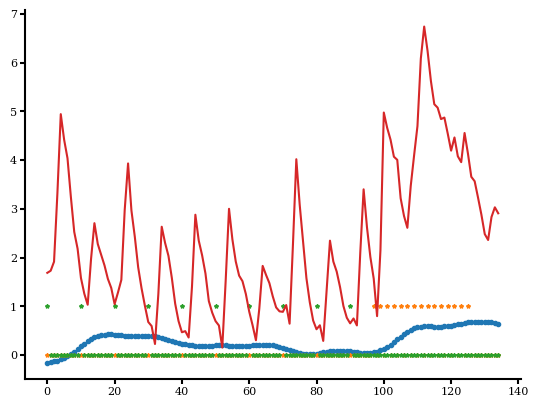

In [49]:
plt.plot(airpuff_trial_avgs_train[10, :],'o')
plt.plot(stim_arr_train[4, seq_periods_train[5][0]:seq_periods_train[5][1]], '*')
plt.plot(stim_arr_train[2, seq_periods_train[5][0]:seq_periods_train[5][1]], '*')
plt.plot(s_train[seq_periods_train[5][0]:seq_periods_train[5][1]])

AttributeError: 'list' object has no attribute 'shape'

In [9]:
X_train = np.vstack([X_white_noise_train, X_airpuff_train, X_reward_train])
X_test = np.vstack([X_white_noise_test, X_airpuff_test, X_reward_test])
y_train = np.hstack([y_white_noise_train, y_airpuff_train, y_reward_train])
y_test = np.hstack([y_white_noise_test, y_airpuff_test, y_reward_test]) 


In [10]:
clf = LogisticRegression(max_iter=4000)
clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)

acc = accuracy_score(y_test, y_hat)
print(acc)

1.0


(array([  60.,    0.,    0.,    0.,    0.,  135.,    0.,    0.,    0.,
        2150.]),
 array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. ]),
 <BarContainer object of 10 artists>)

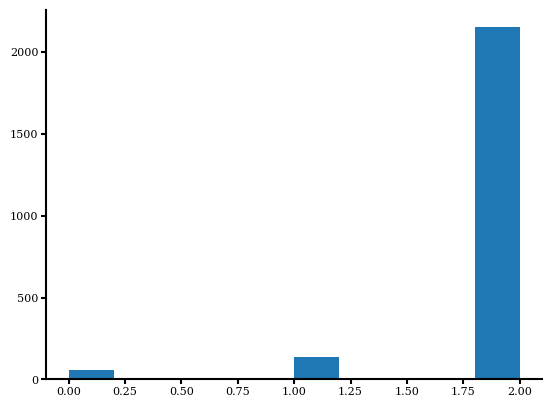

In [11]:
plt.hist(y_test)

In [12]:
X_white_noise_train, y_white_noise_train, white_noise_blocks_train = return_stimuli_blocks(x_train, 
                                                                            seq_periods_train,
                                                                            [1, 5],
                                                                            class_label=0)
X_white_noise_test, y_white_noise_test, white_noise_blocks_test = return_stimuli_blocks(x_test,
                                                                                        seq_periods,
                                                                                        [1, 5],
                                                                                        class_label=0)
X_airpuff_train, y_airpuff_train, airpuff_blocks_train = return_stimuli_blocks(x_train,
                                                                               seq_periods_train,
                                                                               [5, 8],
                                                                               class_label=1)
X_airpuff_test, y_airpuff_test, airpuff_blocks_test = return_stimuli_blocks(x_test,
                                                                               seq_periods,
                                                                               [5, 8],
                                                                               class_label=1)
X_reward_train, y_reward_train, reward_blocks_train = return_stimuli_blocks(x_train, 
                                                                            seq_periods_train,
                                                                            [8, -1],
                                                                            class_label=2)
X_reward_test, y_reward_test, reward_blocks_test = return_stimuli_blocks(x_test,
                                                                         seq_periods,
                                                                         [8, -1],
                                                                         class_label=2)

In [13]:
X = X_white_noise_train + X_white_noise_test + X_airpuff_train + X_airpuff_test + X_reward_train + X_reward_test
y = y_white_noise_train + y_white_noise_test + y_airpuff_train + y_airpuff_test + y_reward_train + y_reward_test

# we want to know the indices of individual stimuli in the concatenated matrix to do leave one out cross validation
white_noise_blocks = np.hstack([[0], white_noise_blocks_train, np.array(white_noise_blocks_test) + white_noise_blocks_train[-1]])
airpuff_blocks_train = np.array(airpuff_blocks_train) + white_noise_blocks[-1]
airpuff_blocks = np.hstack([white_noise_blocks[-1], airpuff_blocks_train, np.array(airpuff_blocks_test) + airpuff_blocks_train[-1]])
reward_blocks_train = np.array(reward_blocks_train) + airpuff_blocks[-1]
reward_blocks = np.hstack([airpuff_blocks[-1], reward_blocks_train, np.array(reward_blocks_test) + reward_blocks_train])

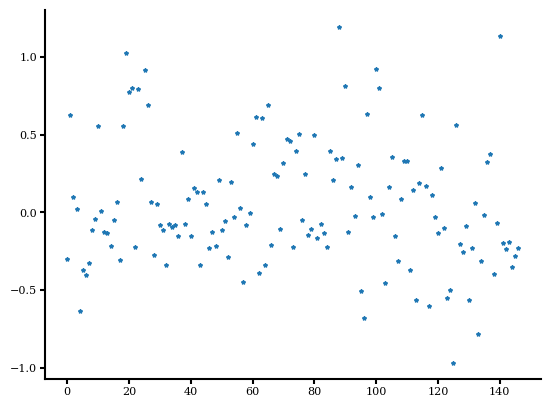

In [32]:
X_airpuff_train = np.array(X_airpuff_train)
plt.plot(X_airpuff_train[10, :], '*')

In [14]:
X = np.vstack(X)
y = np.array(y).astype(int)


In [15]:
for i in range(1, len(airpuff_blocks) - 1):
    train_mask, test_mask = np.ones_like(y, dtype=bool), np.zeros_like(y, dtype=bool)
    train_mask[airpuff_blocks[i-1]:airpuff_blocks[i]] = False
    test_mask[airpuff_blocks[i-1]:airpuff_blocks[i]] = True 

    X_train, y_train = X[train_mask, :], y[train_mask]
    X_test, y_test = X[test_mask, :], y[test_mask]

    # balance the classes
    classes, counts = np.unique(y_train, return_counts=True)
    class_weight = dict(zip(classes, counts))        

    clf = LogisticRegression(max_iter=4000)
    clf.fit(X_train, y_train)
    # y_proba = clf.predict_proba(X_test)
    y_hat = clf.predict(X_test)

    acc = accuracy_score(y_test, y_hat)
    print(acc)

0.0
0.0
0.0


In [48]:
X_white_noise_train.shape, np.array(X_white_noise_test).shape

((720, 147), (120, 147))

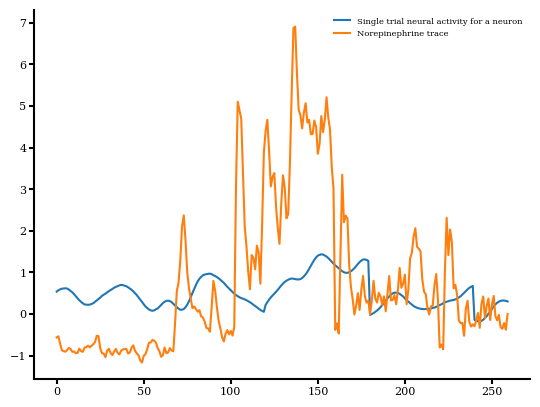

In [23]:
white_noise_trajs = x_train[:, seq_periods_train[1][0]-100:seq_periods_train[1][1]+100]
plt.plot(white_noise_trajs[10, :], label='Single trial neural activity for a neuron')
plt.plot(s_train[seq_periods_train[1][0] - 100:seq_periods_train[1][1] + 100], label='Norepinephrine trace')
plt.legend()

### Do PCA on population activity of the trials. Scatter the loadings color coded by trial type and pre-trial norepinephrine levels

In [8]:
import scipy as sp 

trial_type = []
features = []
s_vals = []
T = 5

s_delta = 5
for i in range(1, 5): 
    white_noise_trajs_train = x_train[:, seq_periods_train[i][0]:seq_periods_train[i][0] + T]
    # compute pop mean rate 
    pop_mean_rate = white_noise_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    # get norepinephrine value just before stimulus 
    s_vals.append(s_train[seq_periods_train[i][0] - s_delta:seq_periods_train[i][0]].mean())
    trial_type.append(0)

for i in range(1, 5): 
    white_noise_trajs_test = x_test[:, seq_periods[i][0]:seq_periods[i][0] + T]
    # compute pop mean rate 
    pop_mean_rate = white_noise_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    # get norepinephrine value just before stimulus 
    s_vals.append(s_test[seq_periods[i][0] - s_delta:seq_periods[i][0]].mean())
    trial_type.append(0)

for i in range(5, 8):
    airpuff_trajs_train = x_train[:, seq_periods_train[i][0]:seq_periods_train[i][0] + T]
    pop_mean_rate = airpuff_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_train[seq_periods_train[i][0] - s_delta:seq_periods_train[i][0]].mean())
    trial_type.append(1)

for i in range(5, 8):
    airpuff_trajs_test = x_test[:, seq_periods[i][0]:seq_periods[i][0] + T]
    pop_mean_rate = airpuff_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_test[seq_periods[i][0] - s_delta:seq_periods[i][0]].mean())
    trial_type.append(1)

for i in range(8, len(seq_periods_train)):
    reward_trajs_train = x_train[:, seq_periods_train[i][0]:seq_periods_train[i][0] + T]
    pop_mean_rate = reward_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_train[seq_periods_train[i][0] - s_delta: seq_periods_train[i][0]].mean())
    trial_type.append(2)

for i in range(8, len(seq_periods)):
    reward_trajs_test = x_test[:, seq_periods[i][0]:seq_periods[i][0] + T]
    pop_mean_rate = reward_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_test[seq_periods[i][0] - s_delta: seq_periods[i][0]].mean())
    trial_type.append(2)

In [9]:
for i in range(1, 5): 
    white_noise_trajs_train = x_train_nk339[:, seq_periods_train_nk339[i][0]:seq_periods_train_nk339[i][0] + T]
    # compute pop mean rate 
    pop_mean_rate = white_noise_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    # get norepinephrine value just before stimulus 
    s_vals.append(s_train_nk339[seq_periods_train_nk339[i][0] - s_delta:seq_periods_train_nk339[i][0]].mean())
    trial_type.append(0)

for i in range(1, 5): 
    white_noise_trajs_test = x_test_nk339[:, seq_periods_nk339[i][0]:seq_periods_nk339[i][0] + T]
    # compute pop mean rate 
    pop_mean_rate = white_noise_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    # get norepinephrine value just before stimulus 
    s_vals.append(s_test_nk339[seq_periods_nk339[i][0] - s_delta:seq_periods_nk339[i][0]].mean())
    trial_type.append(0)

for i in range(5, 8):
    airpuff_trajs_train = x_train_nk339[:, seq_periods_train_nk339[i][0]:seq_periods_train_nk339[i][0] + T]
    pop_mean_rate = airpuff_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_train_nk339[seq_periods_train_nk339[i][0] - s_delta:seq_periods_train_nk339[i][0]].mean())
    trial_type.append(1)

for i in range(5, 8):
    airpuff_trajs_test = x_test_nk339[:, seq_periods_nk339[i][0]:seq_periods_nk339[i][0] + T]
    pop_mean_rate = airpuff_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_test_nk339[seq_periods_nk339[i][0] - s_delta:seq_periods_nk339[i][0]].mean())
    trial_type.append(1)

for i in range(8, len(seq_periods_train)):
    reward_trajs_train = x_train_nk339[:, seq_periods_train_nk339[i][0]:seq_periods_train_nk339[i][0] + T]
    pop_mean_rate = reward_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_train_nk339[seq_periods_train_nk339[i][0] - s_delta: seq_periods_train_nk339[i][0]].mean())
    trial_type.append(2)

for i in range(8, len(seq_periods)):
    reward_trajs_test = x_test_nk339[:, seq_periods_nk339[i][0]:seq_periods_nk339[i][0] + T]
    pop_mean_rate = reward_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_test_nk339[seq_periods_nk339[i][0] - s_delta: seq_periods_nk339[i][0]].mean())
    trial_type.append(2)

In [10]:
# for i in range(1, 5): 
#     white_noise_trajs_train = x_train_nk340[:, seq_periods_train_nk340[i][0]:seq_periods_train_nk340[i][0] + T]
#     # compute pop mean rate 
#     pop_mean_rate = white_noise_trajs_train.mean(axis=0)
#     features.append(pop_mean_rate)
#     # get norepinephrine value just before stimulus 
#     s_vals.append(s_train_nk340[seq_periods_train_nk340[i][0] - s_delta:seq_periods_train_nk340[i][0]].mean())
#     trial_type.append(0)

# for i in range(1, 5): 
#     white_noise_trajs_test = x_test_nk340[:, seq_periods_nk340[i][0]:seq_periods_nk340[i][0] + T]
#     # compute pop mean rate 
#     pop_mean_rate = white_noise_trajs_test.mean(axis=0)
#     features.append(pop_mean_rate)
#     # get norepinephrine value just before stimulus 
#     s_vals.append(s_test_nk340[seq_periods_nk340[i][0] - s_delta:seq_periods_nk340[i][0]].mean())
#     trial_type.append(0)

for i in range(5, 8):
    airpuff_trajs_train = x_train_nk340[:, seq_periods_train_nk340[i][0]:seq_periods_train_nk340[i][0] + T]
    pop_mean_rate = airpuff_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_train_nk340[seq_periods_train_nk340[i][0] - s_delta:seq_periods_train_nk340[i][0]].mean())
    trial_type.append(1)

for i in range(5, 8):
    airpuff_trajs_test = x_test_nk340[:, seq_periods_nk340[i][0]:seq_periods_nk340[i][0] + T]
    pop_mean_rate = airpuff_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_test_nk340[seq_periods_nk340[i][0] - s_delta:seq_periods_nk340[i][0]].mean())
    trial_type.append(1)

for i in range(8, len(seq_periods_train)):
    reward_trajs_train = x_train_nk340[:, seq_periods_train_nk340[i][0]:seq_periods_train_nk340[i][0] + T]
    pop_mean_rate = reward_trajs_train.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_train_nk340[seq_periods_train_nk340[i][0] - s_delta: seq_periods_train_nk340[i][0]].mean())
    trial_type.append(2)

for i in range(8, len(seq_periods)):
    reward_trajs_test = x_test_nk340[:, seq_periods_nk340[i][0]:seq_periods_nk340[i][0] + T]
    pop_mean_rate = reward_trajs_test.mean(axis=0)
    features.append(pop_mean_rate)
    s_vals.append(s_test_nk340[seq_periods_nk340[i][0] - s_delta: seq_periods_nk340[i][0]].mean())
    trial_type.append(2)

In [11]:
features = np.array(features)
features.shape

(39, 5)

In [12]:
U, S, V = sp.sparse.linalg.svds(features, k=2)

In [13]:
feature_loadings = V @ features.T
feature_loadings.shape

(2, 39)

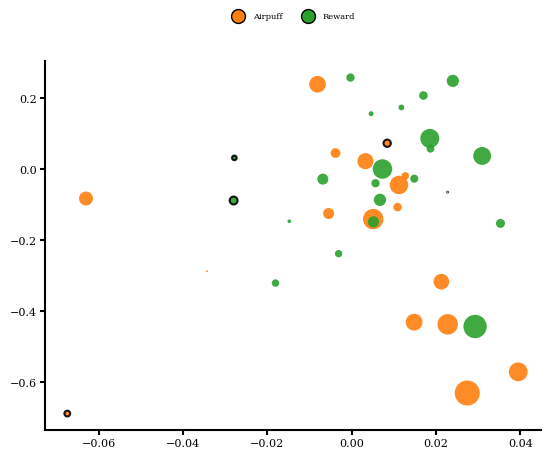

In [14]:

sizes = np.abs(s_vals) * 80
trial_type = np.asarray(trial_type)
neg_mask = np.asarray(s_vals) < 0
pos_mask = ~neg_mask

cmap = plt.get_cmap("tab10")
palette = cmap.colors 

unique_types = np.unique(trial_type)
type_to_color = {t: palette[int(t) % len(palette)] for t in unique_types}

colors_pos = [type_to_color[t] for t in trial_type[pos_mask]]
colors_neg = [type_to_color[t] for t in trial_type[neg_mask]]

plt.scatter(
    feature_loadings[0, pos_mask], feature_loadings[1, pos_mask],
    c=colors_pos, s=sizes[pos_mask], edgecolors="none", alpha=0.9
)
plt.scatter(
    feature_loadings[0, neg_mask], feature_loadings[1, neg_mask],
    c=colors_neg, s=sizes[neg_mask], edgecolors="black", linewidth=1.5, alpha=0.9
)

labels = np.array(["White Noise", "Airpuff", "Reward"])
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=type_to_color[t], markeredgecolor='k',
           markersize=10, label=labels[int(t)])
    for t in unique_types
]

plt.legend(handles=legend_elements, loc="upper center",
           bbox_to_anchor=(0.5, 1.15), ncol=len(unique_types), frameon=False)


In [50]:
len(features)

63

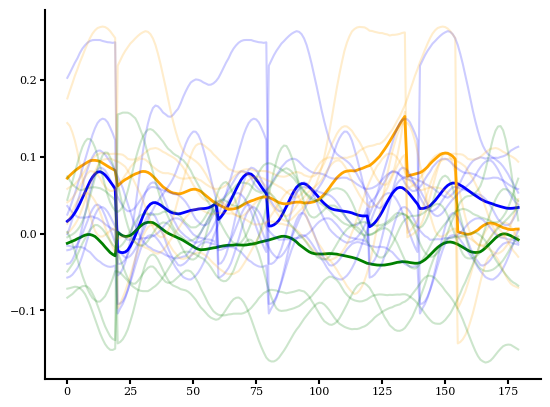

In [53]:
white_noise_features_mean = features[0:8, :].mean(axis=0)
airpuff_features_mean = features[8:14, :].mean(axis=0)
reward_features_mean = features[14:21, :].mean(axis=0)

plt.plot(white_noise_features_mean, linewidth=2, color='blue')
plt.plot(airpuff_features_mean, linewidth=2, color='orange')
plt.plot(reward_features_mean, linewidth=2, color='green')

for i in range(8): plt.plot(features[i, :], color='blue', alpha=0.2)
for i in range(8, 14): plt.plot(features[i, :], color='orange', alpha=0.2)
for i in range(14, 21): plt.plot(features[i, :], color='green', alpha=0.2)

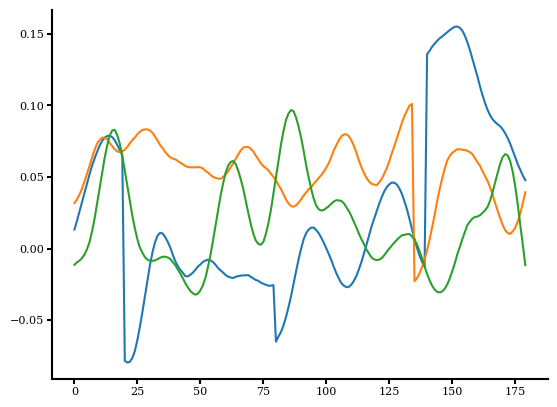

In [165]:
plt.plot(features[2])
plt.plot(features[11])
plt.plot(features[-3])

In [6]:
### Compute gain of excitatory and inhibitory population for different NE values

In [8]:
exc_neurons_nk341 = np.where(cell_types == +1)[0]
inh_neurons_nk341 = np.where(cell_types == -1)[0] 

exc_neurons_nk339 = np.where(cell_types_nk339 == +1)[0]
inh_neurons_nk339 = np.where(cell_types_nk339 == -1)[0] 

exc_neurons_nk340 = np.where(cell_types_nk340 == +1)[0]
inh_neurons_nk340 = np.where(cell_types_nk340 == -1)[0] 


In [93]:
def compute_trial_gains(x_train_dataset,
                        x_test_dataset,
                        s_train_dataset, 
                        s_test_dataset, 
                        seq_periods_train_dataset, 
                        seq_periods_test_dataset,
                        exc_neurons_dataset,
                        inh_neurons_dataset):
    trial_type = []
    exc_gains, inh_gains = [], []
    exc_rates, inh_rates = [], []
    s_vals = []
    T = 50
    s_delta = 5
    stim_delta = 2

    for i in range(1, len(seq_periods_train_dataset)): 
        exc_baseline_rate = x_train_dataset[exc_neurons_dataset, seq_periods_train_dataset[i][0] - s_delta:seq_periods_train_dataset[i][0]].mean(axis=1).mean(axis=0)
        inh_baseline_rate = x_train_dataset[inh_neurons_dataset, seq_periods_train_dataset[i][0] - s_delta:seq_periods_train_dataset[i][0]].mean(axis=1).mean(axis=0)

        exc_gain = x_train_dataset[exc_neurons_dataset, seq_periods_train_dataset[i][0] + stim_delta].mean(axis=0) - exc_baseline_rate
        inh_gain = x_train_dataset[inh_neurons_dataset, seq_periods_train_dataset[i][0] + stim_delta].mean(axis=0) - inh_baseline_rate    

        exc_rates.append(x_train_dataset[exc_neurons_dataset, seq_periods_train_dataset[i][0]:seq_periods_train_dataset[i][0] + T].mean(axis=0))
        inh_rates.append(x_train_dataset[inh_neurons_dataset, seq_periods_train_dataset[i][0]:seq_periods_train_dataset[i][0] + T].mean(axis=0))
        
        exc_gains.append(exc_gain) 
        inh_gains.append(inh_gain) 

        # get norepinephrine value just before stimulus 
        s_vals.append(np.median(s_train_dataset[seq_periods_train_dataset[i][0] - s_delta:seq_periods_train_dataset[i][0]]))
   
        if 1 <= i < 5:
            trial_type.append(0)
        elif 5 <= i < 8: 
            trial_type.append(1)
        else:
            trial_type.append(2)

    for i in range(1, len(seq_periods_test_dataset)): 
        exc_baseline_rate = x_test_dataset[exc_neurons_dataset, seq_periods_test_dataset[i][0] - s_delta:seq_periods_test_dataset[i][0]].mean(axis=1).mean(axis=0)
        inh_baseline_rate = x_test_dataset[inh_neurons_dataset, seq_periods_test_dataset[i][0] - s_delta:seq_periods_test_dataset[i][0]].mean(axis=1).mean(axis=0)

        exc_gain = x_test_dataset[exc_neurons_dataset, seq_periods_test_dataset[i][0] + stim_delta].mean(axis=0) - exc_baseline_rate
        inh_gain = x_test_dataset[inh_neurons_dataset, seq_periods_test_dataset[i][0] + stim_delta].mean(axis=0) - inh_baseline_rate    
        
        exc_rates.append(x_train_dataset[exc_neurons_dataset, seq_periods_test_dataset[i][0]:seq_periods_test_dataset[i][0] + T].mean(axis=0))
        inh_rates.append(x_train_dataset[inh_neurons_dataset, seq_periods_test_dataset[i][0]:seq_periods_test_dataset[i][0] + T].mean(axis=0))
        
        exc_gains.append(exc_gain) 
        inh_gains.append(inh_gain) 
        # get norepinephrine value just before stimulus 
        s_vals.append(np.median(s_test_dataset[seq_periods_test_dataset[i][0] - s_delta:seq_periods_test_dataset[i][0]]))
        if 1 <= i < 5:
            trial_type.append(0)
        elif 5 <= i < 8: 
            trial_type.append(1)
        else:
            trial_type.append(2)
    return exc_gains, inh_gains, exc_rates, inh_rates, s_vals, np.array(trial_type)

In [ ]:
x_train = x_train / x_train.std(axis=1, keepdim=True)
x_train_nk339 = x_train_nk339 / x_train_nk339.std(axis=1, keepdim=True)
x_train_nk340 = x_train_nk340 / x_train_nk340.std(axis=1, keepdim=True)


In [106]:
exc_gains_nk341, inh_gains_nk341, exc_rates_nk341, inh_rates_nk341, s_vals_nk341, trial_types_nk341 = compute_trial_gains(x_train,
                x_test,
                s_train, 
                s_test, 
                seq_periods_train, 
                seq_periods,
                exc_neurons_nk341,
                inh_neurons_nk341)

In [95]:
airpuff_trials = np.where(trial_types_nk341 == 1)[0]
airpuff_trials

array([ 4,  5,  6, 15, 16, 17])

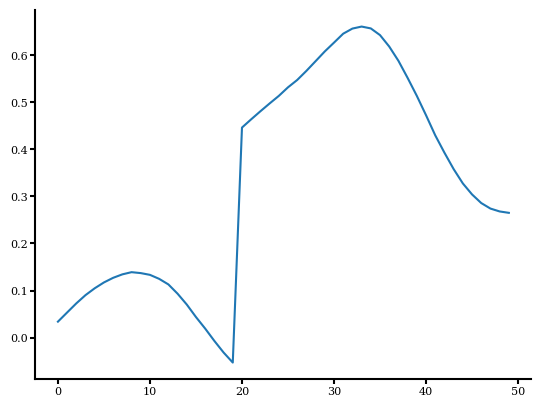

In [105]:
plt.plot(x_train[:, seq_periods_train[5][0]:seq_periods_train[5][0] + 50].mean(axis=0))

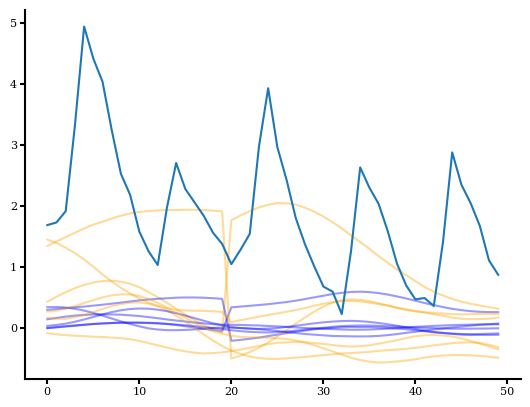

In [107]:
airpuff_trials = np.where(trial_types_nk341 == 1)[0]
for i in airpuff_trials:
    plt.plot(exc_rates_nk341[i], alpha=0.4, c='blue')

    plt.plot(inh_rates_nk341[i], alpha=0.4, c='orange')

plt.plot(s_train[seq_periods_train[5][0]:seq_periods_train[5][0] + 50])

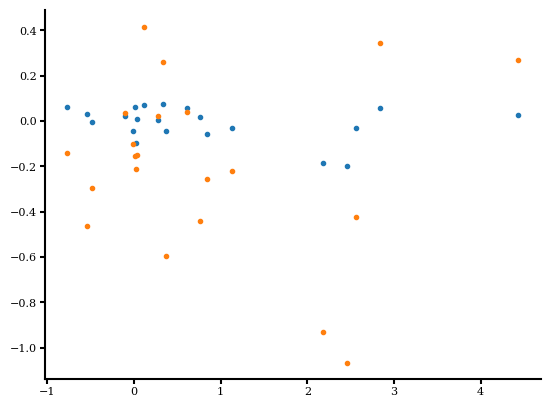

In [108]:
plt.scatter(s_vals_nk341, exc_gains_nk341)
plt.scatter(s_vals_nk341, inh_gains_nk341)

In [111]:
exc_gains_nk339, inh_gains_nk339, exc_rates_nk339, inh_rates_nk339, s_vals_nk339, trial_types_nk339 = compute_trial_gains(x_train_nk339,
                x_test_nk339,
                s_train_nk339, 
                s_test_nk339, 
                seq_periods_train_nk339, 
                seq_periods_nk339,
                exc_neurons_nk339,
                inh_neurons_nk339)

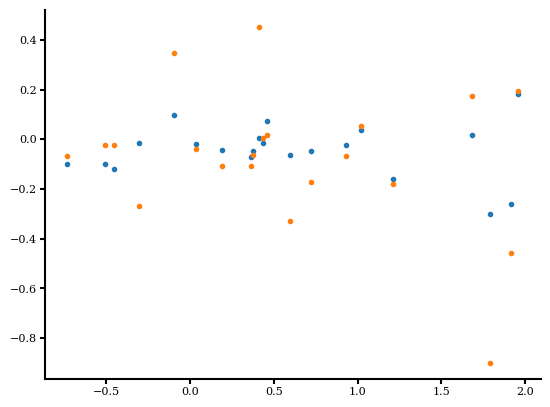

In [112]:
plt.scatter(s_vals_nk339, exc_gains_nk339)
plt.scatter(s_vals_nk339, inh_gains_nk339)

In [113]:
exc_gains_nk340, inh_gains_nk340, _, _, s_vals_nk340, _ = compute_trial_gains(x_train_nk340,
                x_test_nk340,
                s_train_nk340, 
                s_test_nk340, 
                seq_periods_train_nk340, 
                seq_periods_nk340,
                exc_neurons_nk340,
                inh_neurons_nk340)

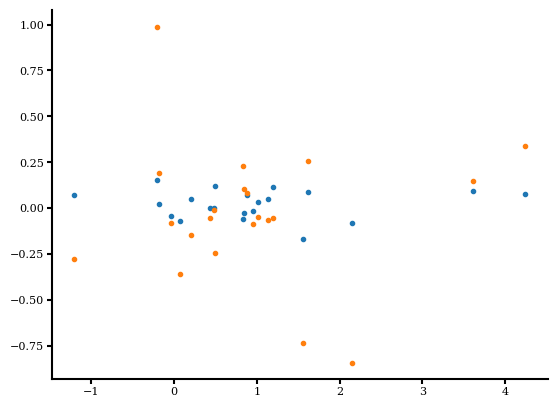

In [114]:
plt.scatter(s_vals_nk340, exc_gains_nk340)
plt.scatter(s_vals_nk340, inh_gains_nk340)

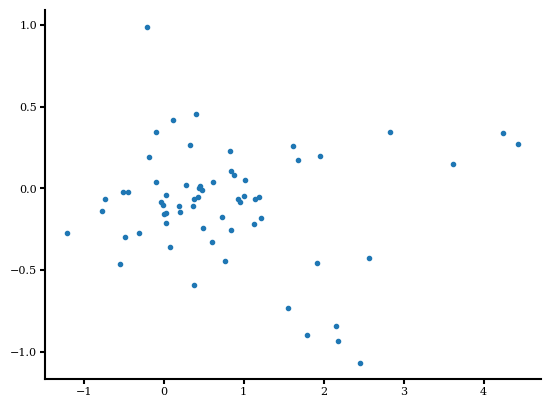

In [115]:
inh_gains_combined = np.hstack([inh_gains_nk339, inh_gains_nk340, inh_gains_nk341])
s_vals_combined = np.hstack([s_vals_nk339, s_vals_nk340, s_vals_nk341])
plt.scatter(s_vals_combined, inh_gains_combined)

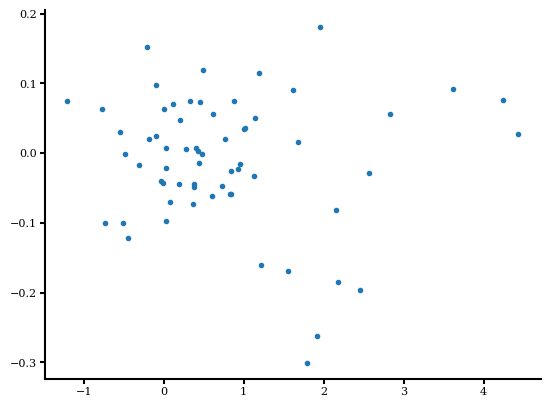

In [116]:
exc_gains_combined = np.hstack([exc_gains_nk339, exc_gains_nk340, exc_gains_nk341])
s_vals_combined = np.hstack([s_vals_nk339, s_vals_nk340, s_vals_nk341])
plt.scatter(s_vals_combined, exc_gains_combined)